# 🧑‍🎨 Notebook 2: Style Transfer

## 🚀 Setup + Load Images

In [1]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# ⚙️ Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")


[INFO] Using device: cuda


## 📥 Load Images

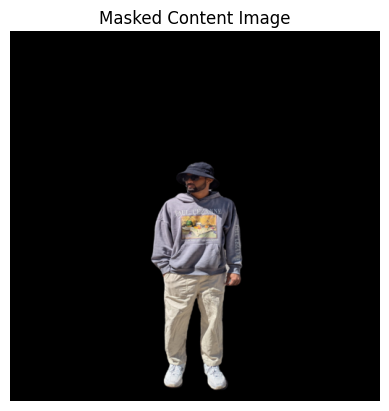

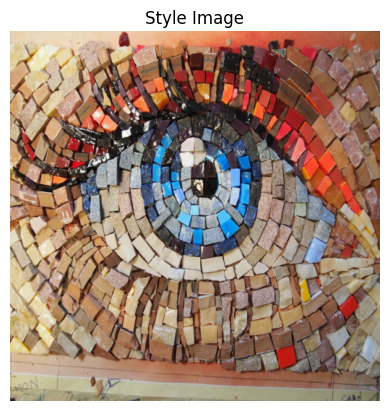

In [3]:
# Paths
content_path = '../outputs/01masked_full.jpg'  # the masked image
style_path = '../styles/mosiac.jpeg'            # your style image
image_size = 512  # resize for both images

# Image transforms
loader = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

# Load content and style
content_img = load_image(content_path)
style_img = load_image(style_path)

# Visualize
def imshow(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

imshow(content_img, title="Masked Content Image")
imshow(style_img, title="Style Image")


## 🎨 Define Content & Style Loss

In [5]:
# Gram Matrix helper for style representation
# Captures texture and style by computing correlations between feature maps
# Used in style loss to compare visual patterns, not exact pixel values
def gram_matrix(input_tensor):
    batch_size, channel, height, width = input_tensor.size()
    features = input_tensor.view(channel, height * width)
    G = torch.mm(features, features.t())
    return G.div(channel * height * width)

# Content Loss Module
# Measures how much the generated image differs from the content image in terms of features.
# Uses MSE loss between feature maps.
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

# Style Loss Module
# Measures how much the style of the generated image differs from the target style.
# Compares Gram matrices of feature maps using MSE.
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input


## 🏗️ Build the Model with Loss Layers

In [7]:
# Load pretrained VGG19
from torchvision.models import vgg19, VGG19_Weights

weights = VGG19_Weights.DEFAULT  # or use .IMAGENET1K_V1 if you want the older fixed version
cnn = vgg19(weights=weights).features.to(device).eval()

# Normalization module (VGG expects input normalized)
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)
    
    def forward(self, img):
        return (img - self.mean) / self.std

# Function to build the model and attach loss layers
def get_model_and_losses(cnn, normalization_mean, normalization_std,
                         style_img, content_img,
                         content_layers=['conv_4'],
                         style_layers=['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']):
    
    cnn = cnn.clone()
    normalization = Normalization(normalization_mean, normalization_std).to(device)
    
    content_losses = []
    style_losses = []
    
    model = nn.Sequential(normalization)
    
    i = 0  # increment every time we see a conv layer
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        elif isinstance(layer, nn.BatchNorm2d):
            name = f'bn_{i}'
        else:
            continue
        
        model.add_module(name, layer)
        
        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)
        
        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # Trim the model after the last loss layer
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], (ContentLoss, StyleLoss)):
            break
    model = model[:i+1]
    
    return model, style_losses, content_losses


In [8]:
# Content loss module
class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()
    
    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

# Style loss module
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = self.gram_matrix(target_feature).detach()
    
    def forward(self, input):
        G = self.gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input
    
    def gram_matrix(self, input):
        b, c, h, w = input.size()
        features = input.view(c, h * w)
        G = torch.mm(features, features.t())
        return G.div(c * h * w)


## 🧱 Build Model with Loss Layers Inserted